In [1]:
import pandas as pd
import numpy as np
import csv
import os
from pathlib import Path
import random
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import matplotlib.pyplot as plt
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, Crippen
from rdkit.ML.Descriptors import MoleculeDescriptors

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from Bio.PDB import PDBParser
from Bio.PDB import NeighborSearch

import scipy.stats as st


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def load_casf2016_ids(path):
    with open(path, "r") as f:
        return set(line.strip().lower() for line in f if line.strip())

casf_ids = load_casf2016_ids("/home/yejin/casf2016_ids.txt")  # ← 너의 경로
print(f"CASF ID 수: {len(casf_ids)}")

CASF ID 수: 285


In [4]:
refined_root = "Database/CASF-2016/coreset/"
train_ids = [d for d in os.listdir(refined_root) if os.path.isdir(os.path.join(refined_root, d))]


In [5]:
valid_ids = []

for pid in train_ids:
    sdf = os.path.join(refined_root, pid, f"{pid}_ligand.sdf")
    pocket = os.path.join(refined_root, pid, f"{pid}_pocket.pdb")
    if os.path.exists(sdf) and os.path.exists(pocket):
        valid_ids.append(pid)

print(f"최종 학습 가능한 샘플 수: {len(valid_ids)}")

최종 학습 가능한 샘플 수: 285


In [6]:
"""preprocessing"""

'preprocessing'

In [7]:
from pathlib import Path
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors as rdmd
import torch
import torch.nn as nn

# -------------------------
# 설정
# -------------------------

refined_root_p = Path("Database/CASF-2016/coreset")

# valid_ids: 예) ['1abc','2def', ...]
# safe_load_molecule: 아래에서 정의

# -------------------------
# 특성 정의 및 계산 함수
# -------------------------
FEATURE_KEYS = [
    'HBD', 'HBA', 'RotBonds', 'AromRings',
    'Heteroatoms', 'TPSA', 'Csp3', 'FormalCharge',
    'MolWt', 'LabuteASA', 'DonorAcceptorRatio'
]

def compute_features(mol):
    # mol 은 반드시 Sanitize 완료 상태라고 가정
    features = {
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromRings': Descriptors.NumAromaticRings(mol),
        'Heteroatoms': rdmd.CalcNumHeteroatoms(mol),  # <-- 수정포인트
        'TPSA': Descriptors.TPSA(mol),
        'Csp3': Descriptors.FractionCSP3(mol),
        'FormalCharge': sum(a.GetFormalCharge() for a in mol.GetAtoms()),
        'MolWt': Descriptors.MolWt(mol),
        'LabuteASA': Descriptors.LabuteASA(mol),
    }
    features['DonorAcceptorRatio'] = features['HBD'] / (features['HBA'] + 1e-5)
    return torch.tensor([features[k] for k in FEATURE_KEYS], dtype=torch.float32)

# -------------------------
# 로딩 유틸
# -------------------------
def safe_load_molecule(sdf_path: Path, mol2_path: Path):
    # 1) SDF 시도 (일반)
    if sdf_path.exists():
        try:
            # 단일 분자 SDF인 경우가 대부분
            mol = Chem.MolFromMolFile(str(sdf_path), sanitize=True, removeHs=False)
            if mol is not None:
                return mol
        except Exception as e:
            print(f"[SDF sanitize 실패] {sdf_path.name}: {e}")

        # 2) SDF 비정상 구조: sanitize=False 후 수동 Sanitize
        try:
            suppl = Chem.SDMolSupplier(str(sdf_path), sanitize=False, removeHs=False)
            mol = next((m for m in suppl if m is not None), None)
            if mol is not None:
                Chem.SanitizeMol(mol)
                return mol
        except Exception as e:
            print(f"[SDF manual sanitize 실패] {sdf_path.name}: {e}")

    # 3) MOL2 대체
    if mol2_path.exists():
        try:
            mol = Chem.MolFromMol2File(str(mol2_path), sanitize=True, removeHs=False)
            if mol is not None:
                return mol
        except Exception as e:
            print(f"[MOL2 sanitize 실패] {mol2_path.name}: {e}")

        try:
            mol = Chem.MolFromMol2File(str(mol2_path), sanitize=False, removeHs=False)
            if mol is not None:
                Chem.SanitizeMol(mol)
                return mol
        except Exception as e:
            print(f"[MOL2 manual sanitize 실패] {mol2_path.name}: {e}")

    return None

# -------------------------
# 실행
# -------------------------
ligand_raw_map = {}
missing_files = 0
load_fail = 0
feat_fail = 0

for pid in tqdm(valid_ids, desc="Ligand RAW features"):
    lig_dir = refined_root_p / pid
    sdf_path = lig_dir / f"{pid}_ligand.sdf"
    mol2_path = lig_dir / f"{pid}_ligand.mol2"

    if not sdf_path.exists() and not mol2_path.exists():
        missing_files += 1
        if missing_files <= 10:
            print(f"[파일없음] {pid}: {sdf_path.name} / {mol2_path.name}")
        continue

    mol = safe_load_molecule(sdf_path, mol2_path)
    if mol is None:
        load_fail += 1
        if load_fail <= 10:
            print(f"[로딩실패] {pid}")
        continue

    try:
        f = compute_features(mol)  # [11]
        ligand_raw_map[pid] = f.detach().clone().float()
    except Exception as e:
        feat_fail += 1
        if feat_fail <= 10:
            print(f"[특성계산실패] {pid}: {e}")

print(f"\n리간드 원특징 완료: {len(ligand_raw_map)} / 전체: {len(valid_ids)}")
print(f"파일없음: {missing_files}, 로딩실패: {load_fail}, 특성계산실패: {feat_fail}")

failed_ligand = [pid for pid in valid_ids if pid not in ligand_raw_map]
if failed_ligand:
    print("❌ 실패 목록 (일부):", failed_ligand[:10])


Ligand RAW features:   0%|                              | 0/285 [00:00<?, ?it/s]

[SDF manual sanitize 실패] 1syi_ligand.sdf: Explicit valence for atom # 13 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3f3d_ligand.sdf: Explicit valence for atom # 2 C, 6, is greater than permitted
[SDF manual sanitize 실패] 2al5_ligand.sdf: Explicit valence for atom # 12 C, 6, is greater than permitted
[SDF manual sanitize 실패] 2wtv_ligand.sdf: Explicit valence for atom # 10 C, 6, is greater than permitted
[SDF manual sanitize 실패] 4ddh_ligand.sdf: Explicit valence for atom # 6 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3zsx_ligand.sdf: Explicit valence for atom # 21 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3u9q_ligand.sdf: Explicit valence for atom # 0 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3gy4_ligand.sdf: Explicit valence for atom # 0 N, 4, is greater than permitted
[SDF manual sanitize 실패] 1qf1_ligand.sdf: Explicit valence for atom # 23 C, 6, is greater than permitted


[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 13 C, 6, is greater than permitted
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 13 C, 6, is greater than permitted
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coo

[SDF manual sanitize 실패] 3gv9_ligand.sdf: Explicit valence for atom # 9 C, 6, is greater than permitted
[SDF manual sanitize 실패] 2zcq_ligand.sdf: Explicit valence for atom # 21 S, 7, is greater than permitted
[SDF manual sanitize 실패] 4kz6_ligand.sdf: Explicit valence for atom # 12 C, 6, is greater than permitted
[SDF manual sanitize 실패] 2qbr_ligand.sdf: Explicit valence for atom # 5 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3fv1_ligand.sdf: Explicit valence for atom # 12 C, 6, is greater than permitted
[SDF manual sanitize 실패] 1owh_ligand.sdf: Explicit valence for atom # 0 N, 4, is greater than permitted
[SDF manual sanitize 실패] 3r88_ligand.sdf: Explicit valence for atom # 9 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3ueu_ligand.sdf: Explicit valence for atom # 2 C, 6, is greater than permitted
[SDF manual sanitize 실패] 1o5b_ligand.sdf: Explicit valence for atom # 2 N, 4, is greater than permitted
[SDF manual sanitize 실패] 4tmn_ligand.sdf: Explicit valence fo

[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 4 N, 4, is greater than permitted
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 4 N, 4, is greater than permitted
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 56 C, 6, is greater than permitted
[21:40:41] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:40:41] Explicit valence for atom # 56 C, 6, is greater than permitted
[21:40:41] Warning: molecule is ta

[SDF manual sanitize 실패] 4owm_ligand.sdf: Explicit valence for atom # 1 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3qqs_ligand.sdf: Explicit valence for atom # 13 C, 6, is greater than permitted
[SDF manual sanitize 실패] 1lpg_ligand.sdf: Explicit valence for atom # 22 N, 4, is greater than permitted
[SDF manual sanitize 실패] 3f3a_ligand.sdf: Explicit valence for atom # 2 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3gbb_ligand.sdf: Explicit valence for atom # 1 C, 6, is greater than permitted
[SDF manual sanitize 실패] 1a30_ligand.sdf: Explicit valence for atom # 6 C, 6, is greater than permitted
[SDF manual sanitize 실패] 2qbq_ligand.sdf: Explicit valence for atom # 5 C, 6, is greater than permitted
[SDF manual sanitize 실패] 4jxs_ligand.sdf: Explicit valence for atom # 3 C, 6, is greater than permitted
[SDF manual sanitize 실패] 4ciw_ligand.sdf: Explicit valence for atom # 6 C, 6, is greater than permitted
[SDF manual sanitize 실패] 3nq9_ligand.sdf: Explicit valence for

In [8]:
AA_CODES = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G',
            'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S',
            'T', 'W', 'Y', 'V']

# 각 아미노산에 대한 Hydrophobicity,numHBD,numHBA, Molecular Weight, Isoelectric Point (pI),Van der Waals volume, Polarity, Flexibility, Side chain pKa, Aromatic / Aliphatic, Charge, Solvent Accessibility,
# Hydrophobicity: 양수일수록 소수성 강함 (Kyte-Doolittle scale 기준)
# Polarity: 극성 여부 (높음/중간/낮음)
# Flexibility: 구조적 유연성 (Gly는 매우 높고, Pro는 rigid)
# VdW Vol.: Van der Waals volume, 대략적인 side chain 부피
# Side chain pKa: side chain이 이온화될 수 있는 경우에만 표시
# Aromatic / Aliphatic: 방향족 고리 여부
# Charge @pH7: 중성(pH7) 기준으로 양전하 / 음전하 / 중성
# Solvent Accessibility (RSA): 상대적 용매 접근성(대략적) – 높은 값은 구조 바깥, 낮은 값은 구조 내부

AA_PROPERTIES = {
    'A': [ 1.8, 0, 0, 89.1, 6.01, 67, 0, 1, -1, 0, 1,  0, 45],
    'R': [-4.5, 1, 3, 174.2,10.76,148, 1, 0, 12.5, 0, 1, +1, 95],
    'N': [-3.5, 1, 1, 132.1, 5.41, 96, 1, 1, -1, 0, 1,  0, 90],
    'D': [-3.5, 0, 2, 133.1, 2.77, 91, 1, 1,  3.9, 0, 1, -1, 95],
    'C': [ 2.5, 0, 1, 121.2, 5.07, 86, 0, 0,  8.3, 0, 1,  0, 20],
    'Q': [-3.5, 1, 1, 146.1, 5.65,114, 1, 1, -1, 0, 1,  0, 90],
    'E': [-3.5, 0, 2, 147.1, 3.22,109, 1, 1,  4.3, 0, 1, -1, 95],
    'G': [-0.4, 0, 0,  75.1, 5.97, 48, 0, 1, -1, 0, 1,  0, 85],
    'H': [-3.2, 1, 1, 155.2, 7.59,118, 1, 1,  6.0, 1, 0, +1, 95],
    'I': [ 4.5, 0, 0, 131.2, 6.05,124, 0, 0, -1, 0, 1,  0, 20],
    'L': [ 3.8, 0, 0, 131.2, 6.01,124, 0, 0, -1, 0, 1,  0, 20],
    'K': [-3.9, 1, 2, 146.2, 9.74,135, 1, 1, 10.5, 0, 1, +1, 95],
    'M': [ 1.9, 0, 0, 149.2, 5.74,124, 0, 1, -1, 0, 1,  0, 50],
    'F': [ 2.8, 0, 0, 165.2, 5.48,135, 0, 0, -1, 1, 0,  0, 20],
    'P': [-1.6, 0, 0, 115.1, 6.30, 90, 0, 0, -1, 0, 1,  0, 50],
    'S': [-0.8, 1, 1, 105.1, 5.68, 73, 1, 1, 13.6, 0, 1,  0, 85],
    'T': [-0.7, 1, 1, 119.1, 5.60, 93, 1, 1, 13.6, 0, 1,  0, 85],
    'W': [-0.9, 1, 1, 204.2, 5.89,163, 1, 0, -1, 1, 0,  0, 20],
    'Y': [-1.3, 1, 1, 181.2, 5.66,141, 1, 0, 10.1, 1, 0,  0, 50],
    'V': [ 4.2, 0, 0, 117.1, 6.00,105, 0, 0, -1, 0, 1,  0, 25],
}

three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D',
    'CYS': 'C', 'GLN': 'Q', 'GLU': 'E', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LEU': 'L', 'LYS': 'K',
    'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S',
    'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

In [11]:
refined_root = "Database/CASF-2016/coreset/"
refined_root_p = Path(refined_root)
parser = PDBParser(QUIET=True)

def get_first_chain_id(pdb_path):
    structure = parser.get_structure("pocket", pdb_path)
    for model in structure:
        for chain in model:
            return chain.id
    return None

def get_residue_feature(residue):
    resname_3 = residue.get_resname().strip()
    if resname_3 not in three_to_one: return None
    aa = three_to_one[resname_3]
    if aa not in AA_PROPERTIES or aa not in AA_CODES: return None
    onehot = [int(aa == x) for x in AA_CODES]
    props = AA_PROPERTIES[aa]
    return torch.tensor(onehot + props, dtype=torch.float32)

def extract_residue_ids_from_pocket(pdb_path):
    structure = parser.get_structure("pocket", pdb_path)
    ids = []
    for model in structure:
        for chain in model:
            for res in chain:
                hetflag, resseq, icode = res.get_id()  # (' ', 42, ' ')
                if hetflag.strip():      # HETATM(리간드/물 등) 스킵
                    continue
                if res.get_resname().strip() not in three_to_one:
                    continue
                ids.append(resseq)
    # 순서 고정
    return sorted(set(ids))
    
parser = PDBParser(QUIET=True)

cavity_raw_map = {}
cavity_meta_map = {}   # ← 새로 추가: pid -> [(chain, resseq, icode, resname3), ...]
failed_cavity = []

for pid in tqdm(valid_ids, desc="Cavity RAW features"):
    pocket_path = refined_root_p / pid / f"{pid}_pocket.pdb"
    try:
        structure = parser.get_structure("pocket", str(pocket_path))
        model = structure[0]

        # 기존처럼 첫 체인만 쓰고 싶으면 get_first_chain_id() 써도 OK
        # 여기선 모든 체인을 순회 (원하면 첫 체인만 쓰도록 바꿔도 됨)
        feats, metas = [], []

        for chain in model:
            chain_id = chain.id
            for res in chain:
                hetflag, resseq, icode = res.get_id()  # (' ', 42, ' ')
                if hetflag.strip():       # HETATM(리간드/물 등) 스킵
                    continue
                resname3 = res.get_resname().strip()
                if resname3 not in three_to_one:
                    continue

                feat = get_residue_feature(res)         # [33]
                if feat is None:
                    continue

                feats.append(feat)
                metas.append((chain_id, int(resseq), (icode or '').strip(), resname3))

        if not feats:
            raise ValueError("유효한 cavity residue가 없습니다.")

        cavity_raw_map[pid]  = torch.stack(feats).float()  # [T, 33]
        cavity_meta_map[pid] = metas                       # 길이 T와 1:1 대응

    except Exception as e:
        failed_cavity.append((pid, str(e)))
        print(f"❌ Cavity {pid}: {e}")

print(f"✅ cavity 원특징 완료: {len(cavity_raw_map)} / 실패: {len(failed_cavity)}")
print(f"✅ cavity 메타 완료: {len(cavity_meta_map)} (예: {next(iter(cavity_meta_map.values()))[:3]})")

Cavity RAW features: 100%|███████████████████| 285/285 [00:01<00:00, 178.83it/s]

✅ cavity 원특징 완료: 285 / 실패: 0
✅ cavity 메타 완료: 285 (예: [(' ', 89, '', 'ASP'), (' ', 91, '', 'THR'), (' ', 92, '', 'ALA')])


In [36]:
from pathlib import Path
from Bio.PDB import PDBParser
import torch, numpy as np
from rdkit import Chem

parser = PDBParser(QUIET=True)

def _meta_to_key(meta):
    """
    cavity_meta_map 항목을 (chain, resseq, icode)로 통일.
    지원:
      (chain, resseq, resname)             -> (chain, resseq, '')
      (chain, resseq, icode, resname)      -> (chain, resseq, icode)
    """
    if len(meta) >= 4:
        chain, resseq, icode, _ = meta[:4]
        return (str(chain), int(resseq), (icode or '').strip())
    elif len(meta) == 3:
        chain, resseq, _ = meta
        return (str(chain), int(resseq), '')
    else:  # 비정형 방어
        chain = str(meta[0]); resseq = int(meta[1])
        icode = meta[2] if len(meta) > 2 else ''
        return (chain, resseq, (icode or '').strip())

def get_ca_xyz_by_meta(pdb_path, metas):
    """
    metas: cavity_meta_map[pid] (체인/잔기/icode/이름 등 포함)
    return: torch.float32 [T,3]
    """
    structure = parser.get_structure("prot", pdb_path)
    model = structure[0]

    # (chain, resseq, icode) -> 좌표
    ca_dict = {}
    fallback = {}
    for chain in model:
        for res in chain:
            het, resseq, icode = res.get_id()
            if het.strip():
                continue
            key = (chain.id, int(resseq), (icode or '').strip())
            if "CA" in res:
                ca_dict[key] = res["CA"].get_coord().astype(np.float32)
            else:
                coords = []
                for an in ("N", "C", "O", "CB"):
                    if an in res:
                        coords.append(res[an].get_coord())
                if coords:
                    fallback[key] = np.mean(np.vstack(coords), axis=0).astype(np.float32)
                else:
                    atoms = list(res.get_atoms())
                    if atoms:
                        fallback[key] = atoms[0].get_coord().astype(np.float32)

    out = []
    for meta in metas:
        key = _meta_to_key(meta)                     # 정확키
        xyz = ca_dict.get(key)
        if xyz is None:
            # icode 없는 메타일 수도 있으니 icode=''도 시도
            key_ni = (key[0], key[1], '')
            xyz = ca_dict.get(key_ni)
        if xyz is None:
            xyz = fallback.get(key) or fallback.get((key[0], key[1], ''))
        if xyz is None:
            xyz = np.zeros(3, dtype=np.float32)
        out.append(xyz)

    arr = np.asarray(out, dtype=np.float32)          # [T,3]
    return torch.from_numpy(arr)

def ligand_centroid_from_sdf_or_mol2(lig_path):
    """SDF/MOL2에서 리간드 좌표 중심 반환(실패 시 0벡터)."""
    mol = None
    p = str(lig_path)
    try:
        if p.lower().endswith(".sdf"):
            suppl = Chem.SDMolSupplier(p, sanitize=False, removeHs=False)
            mol = next((m for m in suppl if m is not None), None)
        else:
            mol = Chem.MolFromMol2File(p, sanitize=False, removeHs=False)
    except Exception:
        mol = None
    if mol is None or mol.GetNumConformers() == 0:
        return torch.zeros(3, dtype=torch.float32)
    conf = mol.GetConformer(0)
    coords = [[conf.GetAtomPosition(i).x,
               conf.GetAtomPosition(i).y,
               conf.GetAtomPosition(i).z] for i in range(mol.GetNumAtoms())]
    if not coords:
        return torch.zeros(3, dtype=torch.float32)
    center = np.mean(np.asarray(coords, dtype=np.float32), axis=0)
    return torch.from_numpy(center)

# ===== 실제 생성 =====
C_xyz_map = {}     # pid -> [T,3]
L_center_map = {}  # pid -> [3]

refined_root_p = Path("Database/CASF-2016/coreset")

for pid in cavity_meta_map.keys():  # ★ metas는 meta_map에서!
    pocket_pdb = refined_root_p / pid / f"{pid}_pocket.pdb"
    sdf_path   = refined_root_p / pid / f"{pid}_ligand.sdf"
    mol2_path  = refined_root_p / pid / f"{pid}_ligand.mol2"
    lig_path   = sdf_path if sdf_path.exists() else mol2_path

    try:
        metas = cavity_meta_map[pid]                              # <-- 여기!
        C_xyz = get_ca_xyz_by_meta(str(pocket_pdb), metas)        # [T,3]
        L_ctr = ligand_centroid_from_sdf_or_mol2(lig_path)        # [3]
        # 길이 안전장치(거의 필요 없겠지만 혹시 몰라)
        T = len(metas)
        if C_xyz.shape[0] != T:
            if C_xyz.shape[0] > T:
                C_xyz = C_xyz[:T]
            else:
                pad = torch.zeros((T - C_xyz.shape[0], 3), dtype=torch.float32)
                C_xyz = torch.cat([C_xyz, pad], dim=0)
        C_xyz_map[pid] = C_xyz
        L_center_map[pid] = L_ctr
    except Exception as e:
        print(f"[coord warn] {pid}: {e}")
        T = len(cavity_meta_map[pid])
        C_xyz_map[pid] = torch.zeros((T,3), dtype=torch.float32)
        L_center_map[pid] = torch.zeros(3, dtype=torch.float32)


[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:33:50] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

In [37]:
import torch
import numpy as np

def build_cavity_aug_map(cavity_raw_map, C_xyz_map, L_center_map, eps=1e-6):
    """
    returns: cavity_aug_map[pid] -> [T, 33+4]
    추가되는 4개: dx, dy, dz, r (리간드 중심 대비)
    """
    cavity_aug_map = {}
    for pid, C_raw in cavity_raw_map.items():
        xyz = C_xyz_map[pid].float()          # [T,3]
        ctr = L_center_map[pid].float()       # [3]
        dxyz = xyz - ctr.unsqueeze(0)         # [T,3]
        r = torch.linalg.norm(dxyz, dim=1, keepdim=True).clamp_min(eps)  # [T,1]
        C_aug = torch.cat([C_raw, dxyz, r], dim=1)  # [T, 37]
        cavity_aug_map[pid] = C_aug
    return cavity_aug_map

# 만들기
cavity_aug_map = build_cavity_aug_map(cavity_raw_map, C_xyz_map, L_center_map)
print("✅ cavity_aug_map 예시 shape:", next(iter(cavity_aug_map.values())).shape)  # [T,37] 기대


✅ cavity_aug_map 예시 shape: torch.Size([57, 37])


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- bilinear 클래스 (학습 때 쓰던 그대로) ----
class BilinearAffinityZ_MLP_LR(nn.Module):
    def __init__(self, lig_dim, cav_dim, proj_dim=64, rank=10, 
                 mu_L=None, sigma_L=None, mu_C=None, sigma_C=None):
        super().__init__()
        # z-score용 통계(고정 버퍼)
        self.register_buffer("mu_L", mu_L.clone().float())
        self.register_buffer("sigma_L", sigma_L.clone().float().clamp_min(1e-6))
        self.register_buffer("mu_C", mu_C.clone().float())
        self.register_buffer("sigma_C", sigma_C.clone().float().clamp_min(1e-6))

        # 인코더
        self.lig_proj = nn.Sequential(
            nn.Linear(lig_dim, proj_dim), nn.ReLU(), nn.LayerNorm(proj_dim), nn.Dropout(0.05)
        )
        self.cav_proj = nn.Sequential(
            nn.Linear(cav_dim, proj_dim), nn.ReLU(), nn.LayerNorm(proj_dim), nn.Dropout(0.05)
        )

        # 저랭크 bilinear: W = U V^T
        self.U = nn.Parameter(torch.empty(proj_dim, rank))
        self.V = nn.Parameter(torch.empty(proj_dim, rank))
        nn.init.xavier_uniform_(self.U); nn.init.xavier_uniform_(self.V)

        # main effects
        self.a = nn.Parameter(torch.zeros(proj_dim))
        self.b = nn.Parameter(torch.zeros(proj_dim))

        # bias
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, L_raw, C_raw, lengths):
        """
        L_raw: [B, 11]
        C_raw: [B, T, 37]  ← 좌표 포함 최신 cavity 특징
        lengths: [B]
        """
        B, T, D = C_raw.shape

        # 1) per-feature z-score
        Lz = (L_raw - self.mu_L) / self.sigma_L              # [B,11]
        Cz_per_res = (C_raw - self.mu_C) / self.sigma_C      # [B,T,37]

        # 2) projection
        Lh = self.lig_proj(Lz)                                # [B,H]
        Ch_full = self.cav_proj(Cz_per_res.reshape(-1, D)).view(B, T, -1)  # [B,T,H]

        # 3) attention score s_t (prior 없이도 OK)
        W = self.U @ self.V.T                                 # [H,H]
        LW = Lh @ W                                           # [B,H]
        # 점수: bilinear term + cavity main (b) as bias
        s = (LW.unsqueeze(1) * Ch_full).sum(-1) + (self.b * Ch_full).sum(-1)  # [B,T]

        # 4) valid mask
        idxs = torch.arange(T, device=C_raw.device).unsqueeze(0).expand(B, T)
        mask = idxs < lengths.unsqueeze(1)

        # 5) attention weights α & weighted pooling
        alpha = torch.softmax(s.masked_fill(~mask, -1e9), dim=1)             # [B,T]
        Ch = (alpha.unsqueeze(2) * Ch_full).sum(1)                            # [B,H]

        # 6) 최종 예측: bilinear + main + bias
        # (W는 이미 위에서 계산됨)
        bilinear = (LW * Ch).sum(1)                                           # [B]
        main = (Lh * self.a).sum(1) + (Ch * self.b).sum(1)                    # [B]
        return bilinear + main + self.bias

# ---- 어텐션 분류기 (bilinear seed에서 파라미터/통계 복제) ----
class AttnBind(nn.Module):
    def __init__(self, bilinear_seed, tau=1.0):
        super().__init__()
        import copy
        # 통계 복제
        self.register_buffer("mu_L", bilinear_seed.mu_L.clone())
        self.register_buffer("sigma_L", bilinear_seed.sigma_L.clone())
        self.register_buffer("mu_C", bilinear_seed.mu_C.clone())
        self.register_buffer("sigma_C", bilinear_seed.sigma_C.clone())

        # proj/저랭크/주효과 복제
        self.lig_proj = copy.deepcopy(bilinear_seed.lig_proj)
        self.cav_proj = copy.deepcopy(bilinear_seed.cav_proj)
        self.U = nn.Parameter(bilinear_seed.U.detach().clone())
        self.V = nn.Parameter(bilinear_seed.V.detach().clone())
        self.a = nn.Parameter(bilinear_seed.a.detach().clone())
        self.b = nn.Parameter(bilinear_seed.b.detach().clone())
        self.bias = nn.Parameter(bilinear_seed.bias.detach().clone())

        # hidden dim(H) 자동 추론
        H = self.U.size(0)
        self.proj_dim = H
        self.tau = tau

        # 분류 head
        self.head = nn.Sequential(
            nn.Linear(2*H, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
        # prior 보정(선택)
        self.delta = nn.Sequential(
            nn.Linear(2*H, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, L_raw, C_raw, lengths, return_alpha=False):
        B, T, D = C_raw.shape  # D가 33 또는 37 어떤 것이든 지원
        # z-score (per-residue)
        Lz = (L_raw - self.mu_L) / self.sigma_L             # [B,11]
        Cz_full = (C_raw - self.mu_C) / self.sigma_C        # [B,T,D]

        # proj
        Lh = self.lig_proj(Lz)                              # [B,H]
        Ch_full = self.cav_proj(Cz_full.reshape(-1, D)).view(B, T, -1)  # [B,T,H]

        # prior α from WD
        W  = self.U @ self.V.T                              # [H,H]
        LW = Lh @ W                                         # [B,H]
        s_core = (LW.unsqueeze(1) * Ch_full).sum(-1)        # [B,T]
        s_cav  = (self.b * Ch_full).sum(-1)                 # [B,T]
        s_lig  = (self.a * Lh).sum(-1, keepdim=True)        # [B,1]
        s = s_core + s_cav + s_lig / lengths.clamp(min=1).unsqueeze(1).to(L_raw.dtype)

        # mask/alpha
        idx = torch.arange(T, device=C_raw.device).unsqueeze(0).expand(B, T)
        mask = (idx < lengths.unsqueeze(1))
        alpha_prior = torch.softmax(s.masked_fill(~mask, -1e9) / self.tau, dim=1)

        feat = torch.cat([Lh.unsqueeze(1).expand(-1, T, -1), Ch_full], dim=-1)     # [B,T,2H]
        delta = self.delta(feat).squeeze(-1).masked_fill(~mask, 0.0)               # [B,T]
        alpha = torch.softmax((s + delta).masked_fill(~mask, -1e9) / self.tau, dim=1)

        # context + logit
        context = torch.bmm(alpha.unsqueeze(1), Ch_full).squeeze(1)                # [B,H]
        logit = self.head(torch.cat([Lh, context], dim=-1)).squeeze(1) + self.bias # [B]
        return (logit, alpha, alpha_prior) if return_alpha else logit


In [68]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 1) WD(affinity) 모델 로드 ----
#  학습 때 썼던 클래스/하이퍼파라미터와 동일해야 함!
def load_wd_model(ckpt_path, proj_dim=64, rank=10):
    ck = torch.load(ckpt_path, map_location="cpu")
    mu_L, sigma_L = ck["mu_L"], ck["sigma_L"]
    mu_C, sigma_C = ck["mu_C"], ck["sigma_C"]

    wd = BilinearAffinityZ_MLP_LR(
        lig_dim=11, cav_dim=37, proj_dim=proj_dim, rank=rank,
        mu_L=mu_L, sigma_L=sigma_L, mu_C=mu_C, sigma_C=sigma_C
    )
    wd.load_state_dict(ck["state_dict"], strict=True)
    wd.to(device).eval()
    return wd, ck["y_mean"], ck["y_std"]

# ---- 2) AttnBind 분류 모델 로드 ----
#  학습 때 저장한 ckpt에 state_dict(+선택: 통계)가 들어있다고 가정
def load_attn_model(ckpt_path, seed_ckpt_path=None, proj_dim=64, rank=10, tau=1.0):
    attn_ck = torch.load(ckpt_path, map_location="cpu")

    if seed_ckpt_path is not None:
        # 시드 WD에서 통계를 복사 (학습때도 이렇게 했다면 일관성↑)
        seed_ck = torch.load(seed_ckpt_path, map_location="cpu")
        seed_model = BilinearAffinityZ_MLP_LR(
            lig_dim=11, cav_dim=37, proj_dim=proj_dim, rank=rank,
            mu_L=seed_ck["mu_L"], sigma_L=seed_ck["sigma_L"],
            mu_C=seed_ck["mu_C"], sigma_C=seed_ck["sigma_C"]
        )
        seed_model.load_state_dict(seed_ck["state_dict"], strict=True)
        model = AttnBind(seed_model, tau=tau)   # 통계/프로젝션/저랭크 가중치 시드 복제
    else:
        # ckpt에 통계가 같이 저장돼있다면 그걸로 초기화하는 버전
        model = AttnBind_from_stats(
            mu_L=attn_ck["mu_L"], sigma_L=attn_ck["sigma_L"],
            mu_C=attn_ck["mu_C"], sigma_C=attn_ck["sigma_C"],
            proj_dim=proj_dim, rank=rank, tau=tau
        )

    model.load_state_dict(attn_ck["state_dict"], strict=False)
    model.to(device).eval()
    return model

# ---- 3) 실제 로드 ----
#   * 파일명은 너가 저장한 이름으로 맞춰줘
wd_ckpt   = "bilinear_mise2_best.pt"        # WD 회귀
attn_ckpt = "attnbind_cls_best.pt"          # AttnBind 분류

seed_model, y_mean, y_std = load_wd_model(wd_ckpt, proj_dim=64, rank=10)
attn = load_attn_model(attn_ckpt, seed_ckpt_path=wd_ckpt, proj_dim=64, rank=10, tau=1.0)

# ---- 4) 인퍼런스: 기존 데이터 맵 그대로 사용 ----
# ==== 인퍼런스: 37D 캐비티 (cavity_aug_map) 사용 ====
pid = "4ty7"  # 보고 싶은 샘플로 바꿔도 OK
print("[PID]", pid)

# 11D ligand, 37D cavity
L_raw = ligand_raw_map[pid]               # [11]
C_raw = cavity_aug_map[pid]               # [T,37]  ← 중요: 이미 만들어둔 37D 맵
T = C_raw.size(0)

L_b   = L_raw.unsqueeze(0).to(device)     # [1,11]
C_b   = C_raw.unsqueeze(0).to(device)     # [1,T,37]
len_b = torch.tensor([T], dtype=torch.long, device=device)

# 방어적 체크
assert C_b.ndim == 3 and C_b.size(-1) == 37, f"C_b shape={C_b.shape}"
assert getattr(attn, "mu_C").numel() == 37, "attn.mu_C dim mismatch"
assert getattr(seed_model, "mu_C").numel() == 37, "wd.mu_C dim mismatch"

# z-score 분포 찍어보기 (디버그)
with torch.no_grad():
    Lz = (L_b - attn.mu_L) / attn.sigma_L
    Cz = (C_b - attn.mu_C) / attn.sigma_C
print("Lz mean/std:", float(Lz.mean()), float(Lz.std()))
print("Cz mean/std:", float(Cz.mean()), float(Cz.std()))

# --- WD 회귀 예측 ---
seed_model.eval()
with torch.no_grad():
    pred_aff = seed_model(L_b, C_b, len_b)
print(f"[WD predicted affinity] {float(pred_aff):.4f}")

# --- AttnBind 분류 예측 ---
attn.eval()
with torch.no_grad():
    logit, alpha, alpha_prior = attn(L_b, C_b, len_b, return_alpha=True)
    prob = torch.sigmoid(logit).item()
print(f"[Attn predicted binding prob] {prob:.4f}")
print("alpha sum:", float(alpha[0,:T].sum()), "max:", float(alpha[0,:T].max()), "min:", float(alpha[0,:T].min()))

# --- Top-k 잔기 (메타 사용) ---
topk = min(5, T)
idxs = alpha[0,:T].detach().cpu().numpy().argsort()[-topk:][::-1]
for i in idxs:
    chain, resseq, icode, res3 = cavity_meta_map[pid][int(i)]
    icode_disp = icode if icode else ' '
    print(f"rank {i}: {res3} {chain}{resseq}{icode_disp} (alpha={alpha[0,i]:.4f})")

[PID] 4ty7
Lz mean/std: 0.340450644493103 0.6457977890968323
Cz mean/std: 0.013719462789595127 1.0353975296020508
[WD predicted affinity] 7.9929
[Attn predicted binding prob] 0.5871
alpha sum: 0.9999999403953552 max: 0.07166285812854767 min: 0.001619250513613224
rank 18: VAL A60  (alpha=0.0717)
rank 23: TRP A141  (alpha=0.0579)
rank 46: TRP A215  (alpha=0.0443)
rank 54: PRO A225  (alpha=0.0396)
rank 36: CYS A191  (alpha=0.0394)


In [66]:
import torch
import pandas as pd

# --- 라벨 세팅 ---
ligand_labels = [
    'HBD','HBA','RotBonds','AromRings','Heteroatoms','TPSA',
    'Csp3','FormalCharge','MolWt','LabuteASA','DonorAcceptorRatio'
]

AA_CODES = ['A','R','N','D','C','Q','E','G','H','I','L','K','M','F','P','S','T','W','Y','V']
prop_labels_13 = [
    "Hydrophobicity","numHBD","numHBA","MolecularWeight","pI",
    "VdW_Volume","Polarity","Flexibility","SideChain_pKa",
    "Aromatic","Aliphatic","Charge","SolventAccessibility"
]
cavity_labels_33 = [f"AA_{a}" for a in AA_CODES] + prop_labels_13
cavity_labels_37 = cavity_labels_33 + ["dX","dY","dZ","r"]

def local_weff_11xD(attn_model, L_raw, C_raw):
    """
    L_raw: [11]
    C_raw: [T,33] 또는 [T,37]  (torch.Tensor)
    반환: (Weff[11,D], contrib_df[11 x D])
    """
    device = next(attn_model.parameters()).device
    attn_model.eval()

    T, D = C_raw.shape
    # 라벨 자동 선택
    if D == 33:
        cav_labels = cavity_labels_33
    elif D == 37:
        cav_labels = cavity_labels_37
    else:
        raise ValueError(f"지원하지 않는 cavity dim D={D} (예상: 33 또는 37)")

    # 평균 캐비티
    Cbar = C_raw.mean(0)                          # [D]

    # z-score
    Lz = (L_raw - attn_model.mu_L.cpu()) / attn_model.sigma_L.cpu()
    Cz = (Cbar  - attn_model.mu_C.cpu()[:D]) / attn_model.sigma_C.cpu()[:D]  # 버퍼가 37이면 33일 때 앞부분만 씀
    Lz = Lz.to(device); Cz = Cz.to(device)

    # 자코비안 계산 준비
    L_raw_ = L_raw.clone().detach().to(device).requires_grad_(True).unsqueeze(0)  # [1,11]
    Cbar_  = Cbar.clone().detach().to(device).requires_grad_(True).unsqueeze(0)   # [1,D]

    # proj 통과
    Lh = attn_model.lig_proj((L_raw_ - attn_model.mu_L)/attn_model.sigma_L)             # [1,H]
    # cav_proj의 in_features는 33 또는 37로 학습됨 → 현재 Cbar_의 D와 일치해야 함
    # (모델이 37D로 학습됐고 입력이 33D면, 여길 통과시키기 전에 37D로 패딩하거나
    #  모델도 33D 버전으로 써야 함. 보통은 C_raw를 37D로 넣는 게 안전)
    Ch = attn_model.cav_proj((Cbar_ - attn_model.mu_C[:D]) / attn_model.sigma_C[:D])     # [1,H]

    H = Lh.size(-1)

    # jac(Lh wrt L_raw): [H,11]
    JL = torch.zeros(H, L_raw_.size(-1), device=device)
    for h in range(H):
        grad = torch.autograd.grad(Lh[0, h], L_raw_, retain_graph=True)[0]  # [1,11]
        JL[h] = grad[0]

    # jac(Ch wrt Cbar): [H,D]
    JC = torch.zeros(H, Cbar_.size(-1), device=device)
    for h in range(H):
        grad = torch.autograd.grad(Ch[0, h], Cbar_, retain_graph=True)[0]   # [1,D]
        JC[h] = grad[0]

    # 프로젝션 공간 W = U V^T
    W_h = attn_model.U @ attn_model.V.T       # [H,H]

    # 입력공간 유효 W: J_L^T · W_h · J_C   → [11,D]
    Weff = JL.T @ W_h @ JC

    # 샘플 기여 행렬 (선형근사)
    contrib = (Lz[:, None] * Weff * Cz[None, :]).detach().cpu()

    df = pd.DataFrame(contrib.numpy(), index=ligand_labels, columns=cav_labels)
    return Weff.detach().cpu(), df

pid = "4ty7"

# 37D로 학습된 모델이라면:
C_raw = cavity_aug_map[pid]   # [T,37]  (dX,dY,dZ,r 포함)
# 33D 모델이라면:
# C_raw = cavity_raw_map[pid] # [T,33]

L_raw = ligand_raw_map[pid]   # [11]

Weff, contrib_df = local_weff_11xD(attn, L_raw, C_raw)
contrib_df.to_csv(f"2_{pid}_contrib_heatmap_11x{C_raw.size(1)}.csv")
print("saved:", f"{pid}_contrib_heatmap_11x{C_raw.size(1)}.csv")


saved: 4ty7_contrib_heatmap_11x37.csv


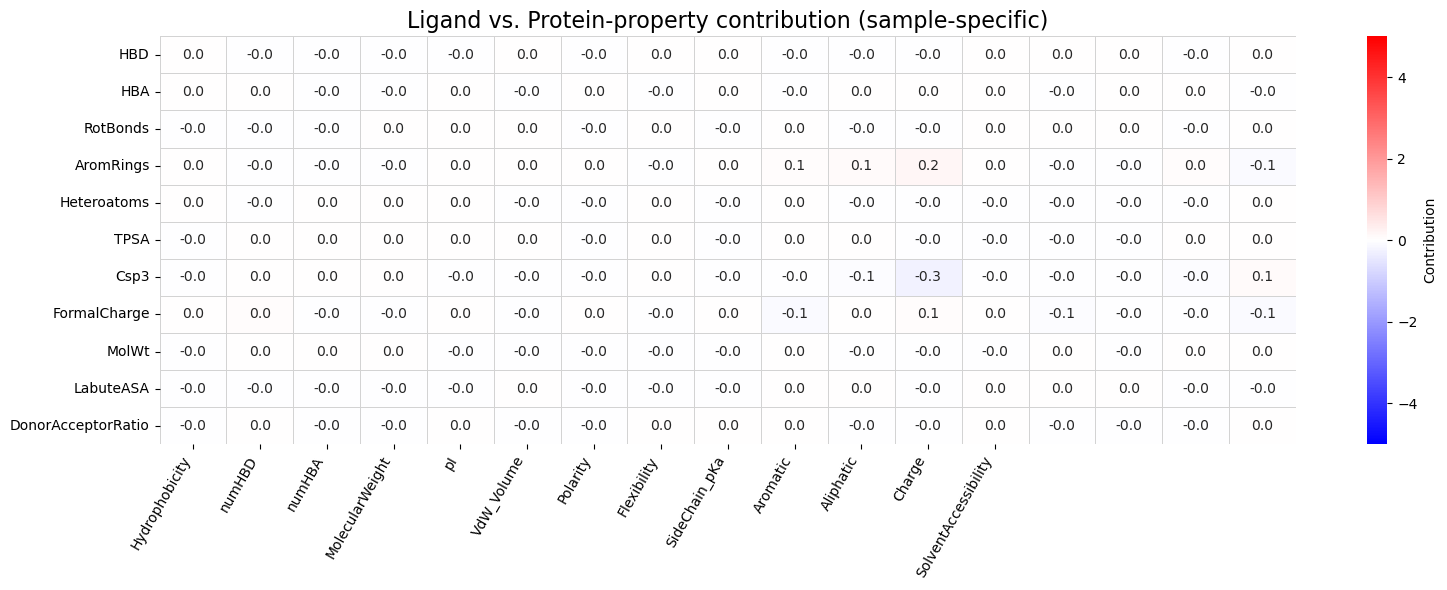

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

ligand_labels = [
    'HBD','HBA','RotBonds','AromRings','Heteroatoms','TPSA',
    'Csp3','FormalCharge','MolWt','LabuteASA','DonorAcceptorRatio'
]

prop_labels = [
    "Hydrophobicity","numHBD","numHBA","MolecularWeight","pI",
    "VdW_Volume","Polarity","Flexibility","SideChain_pKa",
    "Aromatic","Aliphatic","Charge","SolventAccessibility"
]

def save_prop_only_heatmap(contrib_11x13, lig_labels, prop_labels,
                           out_png=None, vmin=-5, vmax=5, annotate=True):
    arr = np.asarray(contrib_11x13)  # shape [11,13]
    plt.figure(figsize=(16,6))
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)  # 0을 흰색
    ax = sns.heatmap(
        arr, annot=annotate, fmt=".1f",
        cmap="bwr", norm=norm,
        cbar_kws={"label": "Contribution"},
        linewidths=0.6, linecolor="lightgray",
        xticklabels=prop_labels, yticklabels=lig_labels
    )
    ax.set_title("Ligand vs. Protein-property contribution (sample-specific)", fontsize=16)
    plt.xticks(rotation=60, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    if out_png: plt.savefig(out_png, dpi=200)
    plt.show()

# CSV 로드하고 prop 컬럼만 자르기 (열 20~32가 prop이라고 가정)
df = pd.read_csv("2_4ty7_contrib_heatmap_11x37.csv", index_col=0)
prop_start_idx = 20
arr_prop = df.iloc[:, prop_start_idx:].values  # [11,13]

# ★ 라벨은 CSV에서 가져오지 말고, 우리가 정의한 걸 그대로 사용
save_prop_only_heatmap(
    arr_prop,
    lig_labels=ligand_labels,
    prop_labels=prop_labels,
    out_png="1g2k_prop_only_heatmap_annot.png",
    vmin=-5, vmax=5,
    annotate=True
)


In [69]:
import csv
import torch

# seed_model = BilinearAffinityZ_MLP_LR(...).load_state_dict(...).eval().to(device)
# ligand_raw_map, cavity_raw_map, (선택) y_true_dict 준비되었다고 가정
out_csv = "casf_pred_affinity.csv"
rows = []
seed_model.eval()

with torch.no_grad():
    for pid in sorted(set(ligand_raw_map) & set(cavity_raw_map)):
        L_raw = ligand_raw_map[pid].unsqueeze(0).to(device)   # [1,11]
        C_raw = cavity_raw_map[pid].unsqueeze(0).to(device)   # [1,T,33]
        lengths = torch.tensor([C_raw.size(1)], device=device)
        y_pred = seed_model(L_raw, C_raw, lengths).item()
        rows.append({"pid": pid, "pred_affinity": y_pred})

# 저장
with open(out_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["pid","pred_affinity"])
    writer.writeheader()
    writer.writerows(rows)

print(f"saved: {out_csv}  (n={len(rows)})")


RuntimeError: The size of tensor a (33) must match the size of tensor b (37) at non-singleton dimension 2